# Analyze identifiability diagnostics: Bernoulli and row-sparsity designs

This notebook aggregates seed-specific diagnostic CSV files from both simulation designs:

```text
../data/raw/solver{solver}_J{J}_K{K}_p{p}_seed{seed}_diag.csv
../data/raw/rowsparse_{distribution}_solver{solver}_J{J}_K{K}_m{m}_dmin{dmin}_seed{seed}_diag.csv
```

It produces:

1. Bernoulli-\(p\) algorithm diagnostics and pure-node gap summaries.
2. Row-sparsity diagnostic-setting summaries for \(\|q_j\|_0\le m\), especially \(m=3,4\).
3. Wide LaTeX tables in the format used in the manuscript/supplement.
4. Optional histograms and branch plots for checking runtime and preprocessing behavior.

By default this notebook filters to `solver == 1`. Change `DEFAULT_SOLVER` in the configuration cell if needed.

In [5]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)
pd.set_option("display.precision", 4)

## 1. Configuration

The recommended layout is:

```text
project/
├── data/
│   ├── raw/          # seed-specific CSVs from cluster jobs
│   └── processed/    # merged summaries and LaTeX tables from this notebook
└── notebooks/
```

Use `CSV_GLOB = "*_diag.csv"` to load both Bernoulli and row-sparsity files.

In [6]:
# Preferred location for seed-specific raw files.
if Path("../data/raw").exists():
    DATA_DIR = Path("../data/raw")
    OUT_DIR = Path("../data/processed")
elif Path("data/raw").exists():
    DATA_DIR = Path("data/raw")
    OUT_DIR = Path("data/processed")
elif Path("../data").exists():
    DATA_DIR = Path("../data")
    OUT_DIR = Path("../data/processed")
elif Path("data").exists():
    DATA_DIR = Path("data")
    OUT_DIR = Path("data/processed")
else:
    DATA_DIR = Path("../data/raw")
    OUT_DIR = Path("../data/processed")

OUT_DIR.mkdir(parents=True, exist_ok=True)
LATEX_DIR = OUT_DIR / "latex_tables"
LATEX_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR = OUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Load all diagnostic CSVs. This includes both Bernoulli and row-sparsity designs.
CSV_GLOB = "*_diag.csv"

# You said you will use solver = 1 by default.
DEFAULT_SOLVER = 1
FILTER_TO_DEFAULT_SOLVER = True

# Drop duplicated simulation rows created by accidental reruns of the same seed/job.
DROP_DUPLICATES = True

# Rounding avoids tiny floating-point differences in p values during grouping.
ROUND_P_DECIMALS = 8

print(f"Current working directory: {Path.cwd().resolve()}")
print(f"DATA_DIR: {DATA_DIR.resolve()}")
print(f"OUT_DIR:  {OUT_DIR.resolve()}")
print(f"LATEX_DIR:{LATEX_DIR.resolve()}")

Current working directory: /home/lemonkey/idQ
DATA_DIR: /home/lemonkey/idQ/data/raw
OUT_DIR:  /home/lemonkey/idQ/data/processed
LATEX_DIR:/home/lemonkey/idQ/data/processed/latex_tables


## 2. Load and clean CSV files

This cell parses metadata from filenames when needed. In particular:

- Bernoulli files are identified by `solver..._J..._K..._p..._seed..._diag.csv`.
- Row-sparsity files are identified by `rowsparse_..._solver..._J..._K..._m..._dmin..._seed..._diag.csv`.

In [7]:
def parse_solver_from_filename(filename):
    m = re.search(r"solver(?P<solver>-?\d+)_", filename)
    return int(m.group("solver")) if m else np.nan


def parse_design_from_filename(filename):
    if filename.startswith("rowsparse_") or "_m" in filename and "_dmin" in filename:
        return "row_sparsity"
    return "bernoulli"


def parse_p_from_filename(filename):
    m = re.search(r"_p(?P<p>[^_]+)_seed", filename)
    return float(m.group("p")) if m else np.nan


def parse_m_from_filename(filename):
    m = re.search(r"_m(?P<m>\d+)_dmin", filename)
    return int(m.group("m")) if m else np.nan


def parse_dmin_from_filename(filename):
    m = re.search(r"_dmin(?P<dmin>\d+)_seed", filename)
    return int(m.group("dmin")) if m else np.nan


def parse_seed_from_filename(filename):
    m = re.search(r"_seed(?P<seed>-?\d+)_diag\.csv$", filename)
    return int(m.group("seed")) if m else np.nan


def parse_rowsparse_dist_from_filename(filename):
    m = re.search(r"rowsparse_(?P<dist>.+?)_solver", filename)
    return m.group("dist") if m else np.nan


files = sorted(DATA_DIR.glob(CSV_GLOB))

file_check = pd.DataFrame({"filename": [f.name for f in files]})

file_check["has_J50"] = file_check["filename"].str.contains(r"_J50_")
file_check["has_J100"] = file_check["filename"].str.contains(r"_J100_")
file_check["has_rowsparse"] = file_check["filename"].str.contains("rowsparse|row_sparse", regex=True)
file_check["has_m"] = file_check["filename"].str.contains(r"_m\d+", regex=True)
file_check["has_dmin"] = file_check["filename"].str.contains(r"_dmin\d+", regex=True)
file_check["has_dist"] = file_check["filename"].str.contains(r"_dist", regex=True)

display(file_check[file_check["has_rowsparse"] | file_check["has_m"]].sort_values("filename"))

print("J values appearing in filenames:")
display(file_check["filename"].str.extract(r"_J(?P<J>\d+)_")["J"].value_counts(dropna=False).sort_index())


if not files:
    raise FileNotFoundError(
        f"No CSV files matched {CSV_GLOB!r} in {DATA_DIR.resolve()}.\n"
        "Edit DATA_DIR or CSV_GLOB in the configuration cell."
    )

print(f"Found {len(files)} diagnostic CSV files.")
for f in files[:15]:
    print("  ", f.name)
if len(files) > 15:
    print("  ...")

dfs = []
for f in files:
    tmp = pd.read_csv(f)
    tmp["source_file"] = f.name

    # Remove accidental header rows before parsing numeric columns.
    if "J" in tmp.columns:
        tmp = tmp[tmp["J"].astype(str) != "J"].copy()

    if "design" not in tmp.columns:
        tmp["design"] = parse_design_from_filename(f.name)
    else:
        tmp["design"] = tmp["design"].replace("", np.nan).fillna(parse_design_from_filename(f.name))

    if "solver" not in tmp.columns:
        tmp["solver"] = parse_solver_from_filename(f.name)
    else:
        tmp["solver"] = tmp["solver"].replace("", np.nan)

    if "p" not in tmp.columns:
        tmp["p"] = parse_p_from_filename(f.name)
    if "m" not in tmp.columns:
        tmp["m"] = parse_m_from_filename(f.name)
    if "min_row_size" not in tmp.columns:
        tmp["min_row_size"] = parse_dmin_from_filename(f.name)
    if "row_size_distribution" not in tmp.columns:
        tmp["row_size_distribution"] = parse_rowsparse_dist_from_filename(f.name)
    if "seed" not in tmp.columns:
        tmp["seed"] = parse_seed_from_filename(f.name)

    # Fill missing metadata from filename if the column exists but values are blank.
    tmp["solver"] = tmp["solver"].replace("", np.nan).fillna(parse_solver_from_filename(f.name))
    tmp["p"] = tmp["p"].replace("", np.nan).fillna(parse_p_from_filename(f.name))
    tmp["m"] = tmp["m"].replace("", np.nan).fillna(parse_m_from_filename(f.name))
    tmp["min_row_size"] = tmp["min_row_size"].replace("", np.nan).fillna(parse_dmin_from_filename(f.name))
    tmp["row_size_distribution"] = tmp["row_size_distribution"].replace("", np.nan).fillna(parse_rowsparse_dist_from_filename(f.name))
    tmp["seed"] = tmp["seed"].replace("", np.nan).fillna(parse_seed_from_filename(f.name))

    dfs.append(tmp)

df = pd.concat(dfs, ignore_index=True)

numeric_cols = [
    "J", "K", "N", "p", "seed", "sim", "solver", "m", "min_row_size",
    "J_basis", "M_basis",
    "identifiable", "branch", "sat_called",
    "identity_original", "not_complete_original",
    "has_pure_node_original", "no_pure_nodes_original",
    "two_col_violation_original",
    "identity_basis", "two_col_violation_basis",
    "basis_time", "trivial_check_time",
    "two_col_check_time", "three_col_check_time",
    "identity_check_time", "sat_time",
    "preprocess_time", "algorithm_time", "diagnostic_time",
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

if "p" in df.columns:
    df["p"] = df["p"].round(ROUND_P_DECIMALS)

# Fill design again after numeric conversion if needed.
df["design"] = df["design"].fillna(df["source_file"].map(parse_design_from_filename))

print("Raw combined shape:", df.shape)
print("Design counts before solver filter:")
display(df["design"].value_counts(dropna=False).to_frame("rows"))
print("Solver counts before solver filter:")
display(df["solver"].value_counts(dropna=False).sort_index().to_frame("rows"))

,filename,has_J50,has_J100,has_rowsparse,has_m,has_dmin,has_dist
0,rowsparse_uniform_solver1_J100_K10_m3_dmin1_se...,False,True,True,True,True,False
1,rowsparse_uniform_solver1_J100_K10_m3_dmin1_se...,False,True,True,True,True,False
2,rowsparse_uniform_solver1_J100_K10_m3_dmin1_se...,False,True,True,True,True,False
3,rowsparse_uniform_solver1_J100_K10_m3_dmin1_se...,False,True,True,True,True,False
4,rowsparse_uniform_solver1_J100_K10_m3_dmin1_se...,False,True,True,True,True,False
...,...,...,...,...,...,...,...
595,rowsparse_uniform_solver1_J50_K10_m4_dmin1_see...,True,False,True,True,True,False
596,rowsparse_uniform_solver1_J50_K10_m4_dmin1_see...,True,False,True,True,True,False
597,rowsparse_uniform_solver1_J50_K10_m4_dmin1_see...,True,False,True,True,True,False
598,rowsparse_uniform_solver1_J50_K10_m4_dmin1_see...,True,False,True,True,True,False


J values appearing in filenames:


J
100    1200
25     1200
50     1200
Name: count, dtype: int64

Found 3600 diagnostic CSV files.
   rowsparse_uniform_solver1_J100_K10_m3_dmin1_seed0_diag.csv
   rowsparse_uniform_solver1_J100_K10_m3_dmin1_seed10_diag.csv
   rowsparse_uniform_solver1_J100_K10_m3_dmin1_seed11_diag.csv
   rowsparse_uniform_solver1_J100_K10_m3_dmin1_seed12_diag.csv
   rowsparse_uniform_solver1_J100_K10_m3_dmin1_seed13_diag.csv
   rowsparse_uniform_solver1_J100_K10_m3_dmin1_seed14_diag.csv
   rowsparse_uniform_solver1_J100_K10_m3_dmin1_seed15_diag.csv
   rowsparse_uniform_solver1_J100_K10_m3_dmin1_seed16_diag.csv
   rowsparse_uniform_solver1_J100_K10_m3_dmin1_seed17_diag.csv
   rowsparse_uniform_solver1_J100_K10_m3_dmin1_seed18_diag.csv
   rowsparse_uniform_solver1_J100_K10_m3_dmin1_seed19_diag.csv
   rowsparse_uniform_solver1_J100_K10_m3_dmin1_seed1_diag.csv
   rowsparse_uniform_solver1_J100_K10_m3_dmin1_seed20_diag.csv
   rowsparse_uniform_solver1_J100_K10_m3_dmin1_seed21_diag.csv
   rowsparse_uniform_solver1_J100_K10_m3_dmin1_seed22_diag.csv
  ...
Raw combined shape

,rows
design,
bernoulli,30000
row_sparsity,6000


Solver counts before solver filter:


,rows
solver,
1,36000


## 3. Validate columns, filter solver, and remove duplicates

For parallel jobs, each seed/job should write one seed-specific CSV. This notebook then safely combines them.

In [8]:
# Reconstruct columns if an older diagnostic file did not save them.
if "sat_called" not in df.columns and "branch" in df.columns:
    df["sat_called"] = df["branch"].isin([5, 6]).astype(int)

if "no_pure_nodes_original" not in df.columns and "has_pure_node_original" in df.columns:
    df["no_pure_nodes_original"] = (1 - df["has_pure_node_original"].astype(int)).astype(int)

components = [
    "basis_time", "trivial_check_time", "two_col_check_time",
    "three_col_check_time", "identity_check_time"
]
if "preprocess_time" not in df.columns and all(c in df.columns for c in components):
    df["preprocess_time"] = df[components].sum(axis=1)

required_cols = [
    "design", "solver", "J", "K", "seed", "sim",
    "identifiable", "branch", "J_basis", "M_basis",
    "identity_basis",
    "two_col_violation_original", "two_col_violation_basis",
    "no_pure_nodes_original",
    "sat_called", "algorithm_time", "preprocess_time", "sat_time",
]


# The recorded identity_original is a legacy diagnostic produced by
# the duplicate-sensitive implementation. Do not use it downstream.
#
# Basis reduction preserves every unit row, so identity_basis gives
# completeness of the generated Q itself.

for col in ["identity_basis", "identifiable", "J_basis", "K"]:
    if df[col].isna().any():
        raise ValueError(f"{col} contains missing values.")

if not df["identity_basis"].isin([0, 1]).all():
    raise ValueError("identity_basis must be binary.")

# Guard against the all-zero-Q edge case in the old get_basis code,
# where an empty basis could have shape (1, 0).
empty_basis_edge = (
    (df["identity_basis"] == 1)
    & (df["J_basis"] < df["K"])
)

print(
    "Rows corrected by the empty-basis guard:",
    int(empty_basis_edge.sum())
)

df["complete"] = (
    (df["identity_basis"] == 1)
    & (df["J_basis"] >= df["K"])
).astype(int)

df["not_complete"] = 1 - df["complete"]

# Completeness is sufficient for identifiability.
assert (df["complete"] <= df["identifiable"]).all()

# A matrix without any pure nodes cannot be complete.
assert (df["no_pure_nodes_original"] <= df["not_complete"]).all()


missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(
        "These required columns are missing. Rerun simulations with the diagnostic code if needed:\n"
        + ", ".join(missing)
    )

if FILTER_TO_DEFAULT_SOLVER:
    before = len(df)
    df = df[df["solver"] == DEFAULT_SOLVER].copy()
    print(f"Filtered to solver == {DEFAULT_SOLVER}: {before} -> {len(df)} rows")

# Duplicate key works for both designs. Bernoulli has m/min_row_size missing; row_sparsity has p missing.
dup_key = [
    "design", "solver", "J", "K", "p", "m", "min_row_size",
    "row_size_distribution", "seed", "sim"
]
dup_key = [c for c in dup_key if c in df.columns]

dup_count = df.duplicated(dup_key).sum()
print(f"Duplicate rows by {dup_key}: {dup_count}")

if DROP_DUPLICATES and dup_count > 0:
    df = df.drop_duplicates(dup_key, keep="last").copy()
    print("After dropping duplicates:", df.shape)

print("Final shape:", df.shape)
display(df.head())

Rows corrected by the empty-basis guard: 0
Filtered to solver == 1: 36000 -> 36000 rows
Duplicate rows by ['design', 'solver', 'J', 'K', 'p', 'm', 'min_row_size', 'row_size_distribution', 'seed', 'sim']: 0
Final shape: (36000, 39)


,J,K,N,seed,sim,solver,op,design,p,m,min_row_size,row_size_distribution,row_size_support,row_size_probs,basis_time,trivial_check_time,two_col_check_time,three_col_check_time,identity_check_time,sat_time,J_basis,algorithm_time,identifiable,branch,branch_label,sat_called,identity_original,not_complete_original,has_pure_node_original,no_pure_nodes_original,two_col_violation_original,identity_basis,two_col_violation_basis,M_basis,preprocess_time,diagnostic_time,source_file,complete,not_complete
0,100,10,10,0,0,1,conj,row_sparsity,NaN,3.0,1.0,uniform,1;2;3,NaN,0.0018,1.1768e-04,0.0006,0.0013,2.2249e-05,0.0,10,0.0038,1,4,identity_submatrix_direct_id,0,1,0,1,0,0,1,0,1024,0.0038,0.0041,rowsparse_uniform_solver1_J100_K10_m3_dmin1_se...,1,0
1,100,10,10,0,1,1,conj,row_sparsity,NaN,3.0,1.0,uniform,1;2;3,NaN,0.0017,9.4298e-05,0.0006,0.0012,1.8180e-05,0.0,10,0.0036,1,4,identity_submatrix_direct_id,0,1,0,1,0,0,1,0,1024,0.0036,0.0040,rowsparse_uniform_solver1_J100_K10_m3_dmin1_se...,1,0
2,100,10,10,0,2,1,conj,row_sparsity,NaN,3.0,1.0,uniform,1;2;3,NaN,0.0016,9.2358e-05,0.0006,0.0012,1.7302e-05,0.0,10,0.0036,1,4,identity_submatrix_direct_id,0,1,0,1,0,0,1,0,1024,0.0036,0.0040,rowsparse_uniform_solver1_J100_K10_m3_dmin1_se...,1,0
3,100,10,10,0,3,1,conj,row_sparsity,NaN,3.0,1.0,uniform,1;2;3,NaN,0.0016,8.9717e-05,0.0006,0.0012,1.6931e-05,0.0,10,0.0036,1,4,identity_submatrix_direct_id,0,1,0,1,0,0,1,0,1024,0.0036,0.0040,rowsparse_uniform_solver1_J100_K10_m3_dmin1_se...,1,0
4,100,10,10,0,4,1,conj,row_sparsity,NaN,3.0,1.0,uniform,1;2;3,NaN,0.0016,8.9156e-05,0.0006,0.0012,1.6869e-05,0.0,10,0.0036,1,4,identity_submatrix_direct_id,0,1,0,1,0,0,1,0,1024,0.0036,0.0040,rowsparse_uniform_solver1_J100_K10_m3_dmin1_se...,1,0


## 4. Check simulation counts

Use these tables to verify that each seed produced the intended number of rows. The actual Monte Carlo sample size is the number of combined rows, not the `N` column.

In [9]:
bernoulli_df = df[df["design"] == "bernoulli"].copy()
rowsparse_df = df[df["design"] == "row_sparsity"].copy()

if len(bernoulli_df):
    bern_seed_counts = (
        bernoulli_df.groupby(["solver", "J", "K", "p", "seed"], dropna=False)
        .size().reset_index(name="n_rows")
        .sort_values(["solver", "K", "J", "p", "seed"])
        .reset_index(drop=True)
    )
    print("Bernoulli seed counts")
    display(bern_seed_counts)

    bern_setting_counts = (
        bernoulli_df.groupby(["solver", "J", "K", "p"], dropna=False)
        .size().reset_index(name="total_rows")
        .sort_values(["solver", "K", "J", "p"])
        .reset_index(drop=True)
    )
    display(bern_setting_counts)

if len(rowsparse_df):
    rowsparse_seed_counts = (
        rowsparse_df.groupby(["solver", "row_size_distribution", "min_row_size", "J", "K", "m", "seed"], dropna=False)
        .size().reset_index(name="n_rows")
        .sort_values(["solver", "row_size_distribution", "min_row_size", "K", "J", "m", "seed"])
        .reset_index(drop=True)
    )
    print("Row-sparsity seed counts")
    display(rowsparse_seed_counts)

    rowsparse_setting_counts = (
        rowsparse_df.groupby(["solver", "row_size_distribution", "min_row_size", "J", "K", "m"], dropna=False)
        .size().reset_index(name="total_rows")
        .sort_values(["solver", "row_size_distribution", "min_row_size", "K", "J", "m"])
        .reset_index(drop=True)
    )
    display(rowsparse_setting_counts)

Bernoulli seed counts


,solver,J,K,p,seed,n_rows
0,1,25,5,0.1,0,10
1,1,25,5,0.1,1,10
2,1,25,5,0.1,2,10
3,1,25,5,0.1,3,10
4,1,25,5,0.1,4,10
...,...,...,...,...,...,...
2995,1,100,10,0.9,95,10
2996,1,100,10,0.9,96,10
2997,1,100,10,0.9,97,10
2998,1,100,10,0.9,98,10


,solver,J,K,p,total_rows
0,1,25,5,0.1,1000
1,1,25,5,0.3,1000
2,1,25,5,0.5,1000
3,1,25,5,0.7,1000
4,1,25,5,0.9,1000
5,1,50,5,0.1,1000
6,1,50,5,0.3,1000
7,1,50,5,0.5,1000
8,1,50,5,0.7,1000
9,1,50,5,0.9,1000


Row-sparsity seed counts


,solver,row_size_distribution,min_row_size,J,K,m,seed,n_rows
0,1,uniform,1.0,25,10,3.0,0,10
1,1,uniform,1.0,25,10,3.0,1,10
2,1,uniform,1.0,25,10,3.0,2,10
3,1,uniform,1.0,25,10,3.0,3,10
4,1,uniform,1.0,25,10,3.0,4,10
...,...,...,...,...,...,...,...,...
595,1,uniform,1.0,100,10,4.0,95,10
596,1,uniform,1.0,100,10,4.0,96,10
597,1,uniform,1.0,100,10,4.0,97,10
598,1,uniform,1.0,100,10,4.0,98,10


,solver,row_size_distribution,min_row_size,J,K,m,total_rows
0,1,uniform,1.0,25,10,3.0,1000
1,1,uniform,1.0,25,10,4.0,1000
2,1,uniform,1.0,50,10,3.0,1000
3,1,uniform,1.0,50,10,4.0,1000
4,1,uniform,1.0,100,10,3.0,1000
5,1,uniform,1.0,100,10,4.0,1000


## 5. Branch labels and derived indicators

The `branch` variable records where the algorithm stops.

In [10]:
BRANCH_LABELS = {
    -1: "basis_J_less_than_K",
     0: "all_zero_column",
     1: "all_one_column",
     2: "two_column_check_failed",
     3: "three_column_check_failed",
     4: "identity_submatrix_direct_id",
     5: "SAT_found_counterexample",
     6: "SAT_unsat_identifiable",
}

df["branch_label"] = df["branch"].map(BRANCH_LABELS)
df["resolved_before_SAT"] = 1 - df["sat_called"].astype(int)
df["SAT_identifiable"] = (df["branch"] == 6).astype(int)
df["SAT_nonidentifiable"] = (df["branch"] == 5).astype(int)
df["direct_identity_branch"] = (df["branch"] == 4).astype(int)
df["two_col_branch"] = (df["branch"] == 2).astype(int)
df["three_col_branch"] = (df["branch"] == 3).astype(int)

bernoulli_df = df[df["design"] == "bernoulli"].copy()
rowsparse_df = df[df["design"] == "row_sparsity"].copy()

display(df[["design", "branch", "branch_label"]].value_counts(dropna=False).sort_index().to_frame("count"))

count
design       branch branch_label                       
bernoulli    -1     basis_J_less_than_K            1114
              0     all_zero_column                 275
              1     all_one_column                  491
              2     two_column_check_failed        2347
              3     three_column_check_failed      3680
              4     identity_submatrix_direct_id   6666
              5     SAT_found_counterexample       1262
              6     SAT_unsat_identifiable        14165
row_sparsity  0     all_zero_column                  51
              2     two_column_check_failed         531
              4     identity_submatrix_direct_id   1265
              6     SAT_unsat_identifiable         4153

## 6. Summary helpers

In [11]:
def binomial_se(x):
    x = pd.Series(x).dropna().astype(float)
    n = len(x)
    if n == 0:
        return np.nan
    p_hat = x.mean()
    return np.sqrt(p_hat * (1 - p_hat) / n)


def summarize_one_group(g):
    identifiable = g["identifiable"].astype(bool)
    complete = g["complete"].astype(bool)
    not_complete = g["not_complete"].astype(bool)
    no_pure = g["no_pure_nodes_original"].astype(bool)
    sat_called = g["sat_called"].astype(bool)

    n = len(g)
    n_id = int(identifiable.sum())
    id_and_not_complete = identifiable & not_complete
    id_and_no_pure = identifiable & no_pure

    out = {
        "n": n,
        "id_prop": identifiable.mean(),
        "id_mcse": binomial_se(identifiable),

        "mean_J_basis": g["J_basis"].mean(),
        "sd_J_basis": g["J_basis"].std(),
        "mean_M_basis": g["M_basis"].mean(),
        "sd_M_basis": g["M_basis"].std(),

        "complete_prop": complete.mean(),
        "complete_mcse": binomial_se(complete),
        "identity_basis_prop": g["identity_basis"].mean(),
        "two_col_violation_original_prop": g["two_col_violation_original"].mean(),
        "two_col_violation_basis_prop": g["two_col_violation_basis"].mean(),
        "sat_called_prop": sat_called.mean(),
        "resolved_before_SAT_prop": (1 - sat_called.astype(int)).mean(),

        "mean_algorithm_time": g["algorithm_time"].mean(),
        "median_algorithm_time": g["algorithm_time"].median(),
        "mean_preprocess_time": g["preprocess_time"].mean(),
        "median_preprocess_time": g["preprocess_time"].median(),
        "mean_sat_time_all": g["sat_time"].mean(),
        "median_sat_time_all": g["sat_time"].median(),

        # Pure-node gap quantities.
        "not_complete_prop": not_complete.mean(),
        "no_pure_prop": no_pure.mean(),
        "id_and_not_complete_prop": id_and_not_complete.mean(),
        "id_and_not_complete_mcse": binomial_se(id_and_not_complete),
        "not_complete_given_id": id_and_not_complete.sum() / n_id if n_id > 0 else np.nan,
        "id_and_no_pure_prop": id_and_no_pure.mean(),
        "id_and_no_pure_mcse": binomial_se(id_and_no_pure),
        "no_pure_given_id": id_and_no_pure.sum() / n_id if n_id > 0 else np.nan,
    }

    if sat_called.any():
        s = g.loc[sat_called]
        out.update({
            "n_SAT": len(s),
            "SAT_identifiable_prop": (s["branch"] == 6).mean(),
            "SAT_nonidentifiable_prop": (s["branch"] == 5).mean(),
            "mean_sat_time_given_SAT": s["sat_time"].mean(),
            "median_sat_time_given_SAT": s["sat_time"].median(),
            "mean_algorithm_time_given_SAT": s["algorithm_time"].mean(),
            "mean_J_basis_given_SAT": s["J_basis"].mean(),
            "mean_M_basis_given_SAT": s["M_basis"].mean(),
        })
    else:
        out.update({
            "n_SAT": 0,
            "SAT_identifiable_prop": np.nan,
            "SAT_nonidentifiable_prop": np.nan,
            "mean_sat_time_given_SAT": np.nan,
            "median_sat_time_given_SAT": np.nan,
            "mean_algorithm_time_given_SAT": np.nan,
            "mean_J_basis_given_SAT": np.nan,
            "mean_M_basis_given_SAT": np.nan,
        })

    return pd.Series(out)


def make_branch_wide(data, group_cols):
    if data.empty:
        return pd.DataFrame()
    branch_table = (
        data.groupby(group_cols + ["branch"], dropna=False)
        .size().reset_index(name="count")
    )
    branch_table["prop"] = branch_table["count"] / branch_table.groupby(group_cols, dropna=False)["count"].transform("sum")
    branch_table["branch_name"] = branch_table["branch"].map(BRANCH_LABELS)
    branch_wide = (
        branch_table.pivot_table(
            index=group_cols,
            columns="branch_name",
            values="prop",
            fill_value=0,
            aggfunc="sum",
        ).reset_index()
    )
    return branch_wide


def format_percent_table(tab, percent_cols, digits=1):
    out = tab.copy()
    for c in percent_cols:
        if c in out.columns:
            out[c] = out[c].map(lambda x: "" if pd.isna(x) else f"{100*x:.{digits}f}")
    return out


def format_float_table(tab, cols, digits=3):
    out = tab.copy()
    for c in cols:
        if c in out.columns:
            out[c] = out[c].map(lambda x: "" if pd.isna(x) else f"{x:.{digits}f}")
    return out

## 7. Bernoulli-\(p\) summaries

These are for the original simulation with \(Q_{jk}\stackrel{i.i.d.}{\sim}\mathrm{Bernoulli}(p)\).

In [12]:
BERN_GROUP = ["solver", "J", "K", "p"]

if len(bernoulli_df):
    bern_summary = (
        bernoulli_df.groupby(BERN_GROUP, dropna=False)
        .apply(summarize_one_group)
        .reset_index()
        .sort_values(["solver", "K", "J", "p"])
        .reset_index(drop=True)
    )
    bern_branch = make_branch_wide(bernoulli_df, BERN_GROUP)
else:
    bern_summary = pd.DataFrame()
    bern_branch = pd.DataFrame()

print("Bernoulli summary")
display(bern_summary)
print("Bernoulli branch proportions")
display(bern_branch)

Bernoulli summary


,solver,J,K,p,n,id_prop,id_mcse,mean_J_basis,sd_J_basis,mean_M_basis,sd_M_basis,complete_prop,complete_mcse,identity_basis_prop,two_col_violation_original_prop,two_col_violation_basis_prop,sat_called_prop,resolved_before_SAT_prop,mean_algorithm_time,median_algorithm_time,mean_preprocess_time,median_preprocess_time,mean_sat_time_all,median_sat_time_all,not_complete_prop,no_pure_prop,id_and_not_complete_prop,id_and_not_complete_mcse,not_complete_given_id,id_and_no_pure_prop,id_and_no_pure_mcse,no_pure_given_id,n_SAT,SAT_identifiable_prop,SAT_nonidentifiable_prop,mean_sat_time_given_SAT,median_sat_time_given_SAT,mean_algorithm_time_given_SAT,mean_J_basis_given_SAT,mean_M_basis_given_SAT
0,1,25,5,0.1,1000.0,0.444,0.0157,4.804,0.7773,23.597,7.8362,0.346,0.0150,0.346,0.556,0.556,0.098,0.902,0.0006,0.0003,0.0003,0.0002,2.5301e-04,0.0000,0.654,0.000,0.098,0.0094,0.2207,0.000,0.0000,0.0000,98.0,1.0000,0.0000,0.0026,0.0026,0.0031,6.1837,27.7245
1,1,25,5,0.3,1000.0,0.951,0.0068,6.161,1.2052,29.323,2.9586,0.389,0.0154,0.389,0.049,0.049,0.562,0.438,0.0021,0.0027,0.0005,0.0005,1.6331e-03,0.0022,0.611,0.000,0.562,0.0157,0.5910,0.000,0.0000,0.0000,562.0,1.0000,0.0000,0.0029,0.0028,0.0034,7.0196,28.0623
2,1,25,5,0.5,1000.0,0.983,0.0041,7.997,1.2233,25.601,2.8955,0.032,0.0056,0.032,0.017,0.017,0.951,0.049,0.0037,0.0037,0.0006,0.0005,3.1049e-03,0.0032,0.968,0.015,0.951,0.0068,0.9674,0.015,0.0038,0.0153,951.0,1.0000,0.0000,0.0033,0.0032,0.0038,8.1188,25.4564
3,1,25,5,0.7,1000.0,0.803,0.0126,7.963,1.1554,17.060,2.7070,0.000,0.0000,0.000,0.049,0.049,0.904,0.096,0.0031,0.0032,0.0005,0.0005,2.5642e-03,0.0026,1.000,0.482,0.803,0.0126,1.0000,0.345,0.0150,0.4296,904.0,0.8883,0.1117,0.0028,0.0027,0.0034,8.0763,17.4148
4,1,25,5,0.9,1000.0,0.000,0.0000,5.393,0.9754,8.160,1.5404,0.000,0.0000,0.000,0.556,0.556,0.019,0.981,0.0003,0.0003,0.0002,0.0002,4.1695e-05,0.0000,1.000,0.992,0.000,0.0000,NaN,0.000,0.0000,NaN,19.0,0.0000,1.0000,0.0022,0.0022,0.0028,6.6316,11.6842
5,1,50,5,0.1,1000.0,0.901,0.0094,5.066,0.4047,30.714,3.4017,0.834,0.0118,0.834,0.099,0.099,0.067,0.933,0.0007,0.0005,0.0005,0.0005,1.9065e-04,0.0000,0.166,0.000,0.067,0.0079,0.0744,0.000,0.0000,0.0000,67.0,1.0000,0.0000,0.0028,0.0027,0.0034,6.3433,28.2687
6,1,50,5,0.3,1000.0,1.000,0.0000,5.257,0.7846,31.814,0.6571,0.896,0.0097,0.896,0.000,0.000,0.104,0.896,0.0009,0.0005,0.0005,0.0005,3.6006e-04,0.0000,0.104,0.000,0.104,0.0097,0.1040,0.000,0.0000,0.0000,104.0,1.0000,0.0000,0.0035,0.0034,0.0041,7.4712,30.2115
7,1,50,5,0.5,1000.0,1.000,0.0000,7.203,1.7084,30.206,1.6181,0.296,0.0144,0.296,0.000,0.000,0.704,0.296,0.0031,0.0035,0.0006,0.0006,2.5125e-03,0.0030,0.704,0.000,0.704,0.0144,0.7040,0.000,0.0000,0.0000,704.0,1.0000,0.0000,0.0036,0.0035,0.0042,8.1293,29.4517
8,1,50,5,0.7,1000.0,0.998,0.0014,9.256,1.1848,22.470,2.4562,0.000,0.0000,0.000,0.000,0.000,1.000,0.000,0.0043,0.0043,0.0006,0.0006,3.7149e-03,0.0037,1.000,0.261,0.998,0.0014,1.0000,0.259,0.0139,0.2595,1000.0,0.9980,0.0020,0.0037,0.0037,0.0043,9.2560,22.4700
9,1,50,5,0.9,1000.0,0.013,0.0036,6.333,0.7802,10.416,1.6798,0.000,0.0000,0.000,0.099,0.099,0.170,0.830,0.0009,0.0005,0.0004,0.0004,3.7425e-04,0.0000,1.000,0.980,0.013,0.0036,1.0000,0.011,0.0033,0.8462,170.0,0.0765,0.9235,0.0022,0.0022,0.0029,6.6647,12.5824


Bernoulli branch proportions


branch_name,solver,J,K,p,SAT_found_counterexample,SAT_unsat_identifiable,all_one_column,all_zero_column,basis_J_less_than_K,identity_submatrix_direct_id,three_column_check_failed,two_column_check_failed
0,1,25,5,0.1,0.000,0.098,0.000,0.011,0.292,0.346,0.000,0.253
1,1,25,5,0.3,0.000,0.562,0.000,0.000,0.001,0.389,0.000,0.048
2,1,25,5,0.5,0.000,0.951,0.000,0.000,0.000,0.032,0.000,0.017
3,1,25,5,0.7,0.101,0.803,0.001,0.000,0.000,0.000,0.047,0.048
4,1,25,5,0.9,0.019,0.000,0.144,0.000,0.162,0.000,0.425,0.250
5,1,25,10,0.1,0.000,0.072,0.000,0.238,0.296,0.006,0.000,0.388
6,1,25,10,0.3,0.000,0.823,0.000,0.001,0.000,0.000,0.000,0.176
7,1,25,10,0.5,0.008,0.933,0.000,0.000,0.000,0.000,0.001,0.058
8,1,25,10,0.7,0.487,0.051,0.001,0.000,0.000,0.000,0.285,0.176
9,1,25,10,0.9,0.000,0.000,0.279,0.000,0.305,0.000,0.078,0.338


## 8. Row-sparsity summaries

These are for the applied diagnostic-setting simulation:

\[
\|q_j\|_0 \le m,
\]

with the default design \(D_j\sim\mathrm{Uniform}\{1,\ldots,m\}\). The primary reviewer-facing settings are \(m=3\) and \(m=4\).

In [13]:
ROW_GROUP = ["solver", "row_size_distribution", "min_row_size", "J", "K", "m"]

if len(rowsparse_df):
    row_summary = (
        rowsparse_df.groupby(ROW_GROUP, dropna=False)
        .apply(summarize_one_group)
        .reset_index()
        .sort_values(["solver", "row_size_distribution", "min_row_size", "K", "J", "m"])
        .reset_index(drop=True)
    )
    row_branch = make_branch_wide(rowsparse_df, ROW_GROUP)
else:
    row_summary = pd.DataFrame()
    row_branch = pd.DataFrame()

print("Row-sparsity summary")
display(row_summary)
print("Row-sparsity branch proportions")
display(row_branch)

Row-sparsity summary


,solver,row_size_distribution,min_row_size,J,K,m,n,id_prop,id_mcse,mean_J_basis,sd_J_basis,mean_M_basis,sd_M_basis,complete_prop,complete_mcse,identity_basis_prop,two_col_violation_original_prop,two_col_violation_basis_prop,sat_called_prop,resolved_before_SAT_prop,mean_algorithm_time,median_algorithm_time,mean_preprocess_time,median_preprocess_time,mean_sat_time_all,median_sat_time_all,not_complete_prop,no_pure_prop,id_and_not_complete_prop,id_and_not_complete_mcse,not_complete_given_id,id_and_no_pure_prop,id_and_no_pure_mcse,no_pure_given_id,n_SAT,SAT_identifiable_prop,SAT_nonidentifiable_prop,mean_sat_time_given_SAT,median_sat_time_given_SAT,mean_algorithm_time_given_SAT,mean_J_basis_given_SAT,mean_M_basis_given_SAT
0,1,uniform,1.0,25,10,3.0,1000.0,0.641,0.0152,16.038,2.3720,583.009,133.9451,0.002,0.0014,0.002,0.359,0.359,0.639,0.361,0.1122,0.1415,0.0041,0.0042,0.1081,0.1367,0.998,0.000,0.639,0.0152,0.9969,0.000,0.000,0.0000,639.0,1.0,0.0,0.1691,0.1702,0.1742,16.5634,640.2128
1,1,uniform,1.0,25,10,4.0,1000.0,0.786,0.0130,18.545,2.2661,477.437,104.8889,0.000,0.0000,0.000,0.214,0.214,0.786,0.214,0.1342,0.1567,0.0047,0.0050,0.1295,0.1516,1.000,0.001,0.786,0.0130,1.0000,0.001,0.001,0.0013,786.0,1.0,0.0,0.1647,0.1636,0.1700,18.8893,498.7392
2,1,uniform,1.0,50,10,3.0,1000.0,0.992,0.0028,16.621,4.2362,930.862,71.2209,0.117,0.0102,0.117,0.008,0.008,0.875,0.125,0.2278,0.2319,0.0062,0.0059,0.2216,0.2257,0.883,0.000,0.875,0.0105,0.8821,0.000,0.000,0.0000,875.0,1.0,0.0,0.2533,0.2358,0.2598,17.5303,920.7554
3,1,uniform,1.0,50,10,4.0,1000.0,0.999,0.0010,20.975,4.7156,850.803,86.1990,0.021,0.0045,0.021,0.001,0.001,0.978,0.022,0.2996,0.2883,0.0079,0.0076,0.2917,0.2802,0.979,0.000,0.978,0.0046,0.9790,0.000,0.000,0.0000,978.0,1.0,0.0,0.2982,0.2840,0.3063,21.2127,847.2628
4,1,uniform,1.0,100,10,3.0,1000.0,1.000,0.0000,11.964,3.3102,1019.021,10.6924,0.703,0.0144,0.703,0.000,0.000,0.297,0.703,0.0872,0.0037,0.0046,0.0037,0.0827,0.0000,0.297,0.000,0.297,0.0144,0.2970,0.000,0.000,0.0000,297.0,1.0,0.0,0.2783,0.2623,0.2848,16.6128,1007.2357
5,1,uniform,1.0,100,10,4.0,1000.0,1.000,0.0000,14.689,4.8818,1004.208,24.6484,0.422,0.0156,0.422,0.000,0.000,0.578,0.422,0.1733,0.2240,0.0061,0.0052,0.1672,0.2183,0.578,0.000,0.578,0.0156,0.5780,0.000,0.000,0.0000,578.0,1.0,0.0,0.2893,0.2692,0.2969,18.1125,989.7578


Row-sparsity branch proportions


branch_name,solver,row_size_distribution,min_row_size,J,K,m,SAT_unsat_identifiable,all_zero_column,identity_submatrix_direct_id,two_column_check_failed
0,1,uniform,1.0,25,10,3.0,0.639,0.044,0.002,0.315
1,1,uniform,1.0,25,10,4.0,0.786,0.007,0.000,0.207
2,1,uniform,1.0,50,10,3.0,0.875,0.000,0.117,0.008
3,1,uniform,1.0,50,10,4.0,0.978,0.000,0.021,0.001
4,1,uniform,1.0,100,10,3.0,0.297,0.000,0.703,0.000
5,1,uniform,1.0,100,10,4.0,0.578,0.000,0.422,0.000


## 9. Compact display tables

These display tables are not used for the wide LaTeX format below; they are for quick inspection.

In [14]:
summary_display_cols = [
    "solver", "J", "K", "p", "m", "min_row_size", "row_size_distribution", "n",
    "id_prop", "identity_prop", "two_col_violation_basis_prop", "sat_called_prop",
    "mean_J_basis", "mean_M_basis", "mean_algorithm_time", "mean_sat_time_given_SAT",
    "id_and_not_complete_prop", "not_complete_given_id", "id_and_no_pure_prop", "no_pure_given_id",
]

percent_cols = [
    "id_prop", "identity_prop", "two_col_violation_basis_prop", "sat_called_prop",
    "id_and_not_complete_prop", "not_complete_given_id", "id_and_no_pure_prop", "no_pure_given_id",
]
float_cols = ["mean_J_basis", "mean_M_basis", "mean_algorithm_time", "mean_sat_time_given_SAT"]

if len(bern_summary):
    bern_display = bern_summary[[c for c in summary_display_cols if c in bern_summary.columns]].copy()
    bern_display = format_percent_table(bern_display, percent_cols, digits=1)
    bern_display = format_float_table(bern_display, float_cols, digits=3)
    print("Bernoulli compact display")
    display(bern_display)
else:
    bern_display = pd.DataFrame()

if len(row_summary):
    row_display = row_summary[[c for c in summary_display_cols if c in row_summary.columns]].copy()
    row_display = format_percent_table(row_display, percent_cols, digits=1)
    row_display = format_float_table(row_display, float_cols, digits=3)
    print("Row-sparsity compact display")
    display(row_display)
else:
    row_display = pd.DataFrame()

Bernoulli compact display


,solver,J,K,p,n,id_prop,two_col_violation_basis_prop,sat_called_prop,mean_J_basis,mean_M_basis,mean_algorithm_time,mean_sat_time_given_SAT,id_and_not_complete_prop,not_complete_given_id,id_and_no_pure_prop,no_pure_given_id
0,1,25,5,0.1,1000.0,44.4,55.6,9.8,4.804,23.597,0.001,0.003,9.8,22.1,0.0,0.0
1,1,25,5,0.3,1000.0,95.1,4.9,56.2,6.161,29.323,0.002,0.003,56.2,59.1,0.0,0.0
2,1,25,5,0.5,1000.0,98.3,1.7,95.1,7.997,25.601,0.004,0.003,95.1,96.7,1.5,1.5
3,1,25,5,0.7,1000.0,80.3,4.9,90.4,7.963,17.060,0.003,0.003,80.3,100.0,34.5,43.0
4,1,25,5,0.9,1000.0,0.0,55.6,1.9,5.393,8.160,0.000,0.002,0.0,,0.0,
5,1,50,5,0.1,1000.0,90.1,9.9,6.7,5.066,30.714,0.001,0.003,6.7,7.4,0.0,0.0
6,1,50,5,0.3,1000.0,100.0,0.0,10.4,5.257,31.814,0.001,0.003,10.4,10.4,0.0,0.0
7,1,50,5,0.5,1000.0,100.0,0.0,70.4,7.203,30.206,0.003,0.004,70.4,70.4,0.0,0.0
8,1,50,5,0.7,1000.0,99.8,0.0,100.0,9.256,22.470,0.004,0.004,99.8,100.0,25.9,26.0
9,1,50,5,0.9,1000.0,1.3,9.9,17.0,6.333,10.416,0.001,0.002,1.3,100.0,1.1,84.6


Row-sparsity compact display


,solver,J,K,m,min_row_size,row_size_distribution,n,id_prop,two_col_violation_basis_prop,sat_called_prop,mean_J_basis,mean_M_basis,mean_algorithm_time,mean_sat_time_given_SAT,id_and_not_complete_prop,not_complete_given_id,id_and_no_pure_prop,no_pure_given_id
0,1,25,10,3.0,1.0,uniform,1000.0,64.1,35.9,63.9,16.038,583.009,0.112,0.169,63.9,99.7,0.0,0.0
1,1,25,10,4.0,1.0,uniform,1000.0,78.6,21.4,78.6,18.545,477.437,0.134,0.165,78.6,100.0,0.1,0.1
2,1,50,10,3.0,1.0,uniform,1000.0,99.2,0.8,87.5,16.621,930.862,0.228,0.253,87.5,88.2,0.0,0.0
3,1,50,10,4.0,1.0,uniform,1000.0,99.9,0.1,97.8,20.975,850.803,0.300,0.298,97.8,97.9,0.0,0.0
4,1,100,10,3.0,1.0,uniform,1000.0,100.0,0.0,29.7,11.964,1019.021,0.087,0.278,29.7,29.7,0.0,0.0
5,1,100,10,4.0,1.0,uniform,1000.0,100.0,0.0,57.8,14.689,1004.208,0.173,0.289,57.8,57.8,0.0,0.0


## 10. Wide LaTeX table exporter

This produces tables in the style:

```latex
\begin{table}[!htbp]
\centering
\caption{...}
\label{tab:...}
\resizebox{\textwidth}{!}{%
\begin{tabular}{c !{\vrule width 0.8pt} cc ...}
...
\end{tabular}%
}
\end{table}
```

The table columns are grouped by \(J\), with \(K\) nested inside each \(J\) group. The row variable is usually \(p\) for Bernoulli and \(m\) for row-sparsity.

In [15]:
def latex_escape_label_value(var, value):
    if pd.isna(value):
        return ""
    if var == "p":
        return f"{float(value):g}"
    if var in {"m", "K", "J", "min_row_size"}:
        return f"{int(value)}" if float(value).is_integer() else f"{float(value):g}"
    return str(value)


def format_metric_value(x, decimals=3, as_percent=False):
    if pd.isna(x):
        return ""
    val = 100 * x if as_percent else x
    return f"{val:.{decimals}f}"


def make_wide_metric_table(
    summary,
    row_var,
    metric,
    caption,
    label,
    J_values=None,
    K_values=None,
    row_values=None,
    decimals=3,
    as_percent=False,
    row_header=None,
    table_width="\\textwidth",
):
    # Create a wide LaTeX table with row_var as rows and J/K as grouped columns.
    # summary must contain columns row_var, J, K, and metric.
    # Set as_percent=True to display 100*metric; otherwise raw values are displayed.
    if summary.empty:
        raise ValueError("summary is empty")
    for c in [row_var, "J", "K", metric]:
        if c not in summary.columns:
            raise ValueError(f"Missing required column: {c}")

    tab = summary.copy()

    if J_values is None:
        J_values = sorted(tab["J"].dropna().unique())
    if K_values is None:
        K_values = sorted(tab["K"].dropna().unique())
    if row_values is None:
        row_values = sorted(tab[row_var].dropna().unique())

    J_values = list(J_values)
    K_values = list(K_values)
    row_values = list(row_values)

    nK = len(K_values)
    if nK == 0:
        raise ValueError("No K values available")

    # Column specification: c !{rule} cc !{rule} cc ...
    colspec = "c" + "".join([" !{\\vrule width 0.8pt} " + ("c" * nK) for _ in J_values])

    lines = []
    lines.append(r"\begin{table}[!htbp]")
    lines.append(r"\centering")
    lines.append(f"\\caption{{{caption}}}")
    lines.append(f"\\label{{{label}}}")
    lines.append(f"\\resizebox{{{table_width}}}{{!}}{{%")
    lines.append(f"\\begin{{tabular}}{{{colspec}}}")
    lines.append(r"  \toprule")

    header_parts = []
    for idx, J in enumerate(J_values):
        j_label = f"$J{{=}}{int(J) if float(J).is_integer() else J}$"
        if idx < len(J_values) - 1:
            header_parts.append(
                f"\\multicolumn{{{nK}}}{{c!{{\\vrule width 0.8pt}}}}{{{j_label}}}"
            )
        else:
            header_parts.append(
                f"\\multicolumn{{{nK}}}{{c}}{{{j_label}}}"
            )

    lines.append("  & " + " & ".join(header_parts) + r" \\")

    cmid = []
    start = 2
    for _ in J_values:
        end = start + nK - 1
        cmid.append(f"\\cmidrule(lr){{{start}-{end}}}")
        start = end + 1
    lines.append("  " + "".join(cmid))

    if row_header is None:
        row_header = f"${row_var}$"

    k_headers = [
        f"$K{{=}}{int(K) if float(K).is_integer() else K}$"
        for J in J_values
        for K in K_values
    ]
    lines.append("  " + row_header + " & " + " & ".join(k_headers) + r" \\ \midrule")

    # If there are duplicate entries per (row_var,J,K), average them.
    mean_tab = (
        tab.groupby([row_var, "J", "K"], dropna=False)[metric]
        .mean()
        .reset_index()
    )

    for rv in row_values:
        row_cells = [latex_escape_label_value(row_var, rv)]
        for J in J_values:
            for K in K_values:
                cell = mean_tab[
                    (mean_tab[row_var] == rv)
                    & (mean_tab["J"] == J)
                    & (mean_tab["K"] == K)
                ]
                if cell.empty:
                    row_cells.append("")
                else:
                    row_cells.append(
                        format_metric_value(
                            cell.iloc[0][metric],
                            decimals=decimals,
                            as_percent=as_percent,
                        )
                    )
        lines.append("  " + " & ".join(row_cells) + r" \\")

    lines.append(r"  \bottomrule")
    lines.append(r"\end{tabular}%")
    lines.append(r"}")
    lines.append(r"\end{table}")

    return "\n".join(lines)


def save_latex_table(tex, filename):
    path = LATEX_DIR / filename
    path.write_text(tex)
    print(f"Wrote {path.resolve()}")
    return path

## 11. Wide LaTeX tables for Bernoulli-\(p\) experiment

These tables use rows indexed by \(p\). Solver and `N` are intentionally omitted from the LaTeX table body.

Set the desired `J_VALUES`, `K_VALUES`, and `P_VALUES` to match the manuscript layout.

In [16]:
# Customize these to match your actual simulation grid.
J_VALUES = [25, 50, 100]
K_VALUES = [5, 10]
P_VALUES = [0.1, 0.3, 0.5, 0.7, 0.9]

if len(bern_summary):
    bern_for_latex = bern_summary.copy()

    # Keep rows that are actually present, so the exporter still works if your grid differs.
    J_values_bern = [j for j in J_VALUES if j in set(bern_for_latex["J"])] or sorted(bern_for_latex["J"].dropna().unique())
    K_values_bern = [k for k in K_VALUES if k in set(bern_for_latex["K"])] or sorted(bern_for_latex["K"].dropna().unique())
    P_values_bern = [p for p in P_VALUES if np.any(np.isclose(bern_for_latex["p"], p))] or sorted(bern_for_latex["p"].dropna().unique())

    bern_latex_specs = [
        ("id_prop", "Proportion of identifiable $\\QQ$-matrices under the Bernoulli-$p$ design.", "tab:bern_id_prop", "bern_id_prop.tex", 3, False),
        ("identity_prop", "Proportion of Bernoulli-$p$ $\\QQ$-matrices containing an identity submatrix.", "tab:bern_identity_prop", "bern_identity_prop.tex", 3, False),
        ("two_col_violation_basis_prop", "Proportion of Bernoulli-$p$ $\\QQ$-matrices violating the two-column necessary condition after basis reduction.", "tab:bern_two_col_basis", "bern_two_col_basis.tex", 3, False),
        ("sat_called_prop", "Proportion of Bernoulli-$p$ $\\QQ$-matrices passed to the SAT solver.", "tab:bern_sat_called", "bern_sat_called.tex", 3, False),
        ("id_and_not_complete_prop", "Proportion of Bernoulli-$p$ $\\QQ$-matrices identifiable but not complete.", "tab:bern_id_not_complete", "bern_id_not_complete.tex", 3, False),
        ("not_complete_given_id", "Conditional proportion of not-complete matrices among identifiable Bernoulli-$p$ $\\QQ$-matrices.", "tab:bern_not_complete_given_id", "bern_not_complete_given_id.tex", 3, False),
        ("id_and_no_pure_prop", "Proportion of Bernoulli-$p$ $\\QQ$-matrices identifiable while containing no pure nodes.", "tab:bern_id_no_pure", "bern_id_no_pure.tex", 3, False),
        ("no_pure_given_id", "Conditional proportion of no-pure-node matrices among identifiable Bernoulli-$p$ $\\QQ$-matrices.", "tab:bern_no_pure_given_id", "bern_no_pure_given_id.tex", 3, False),
        ("mean_algorithm_time", "Average runtime in seconds under the Bernoulli-$p$ design.", "tab:bern_runtime", "bern_runtime.tex", 3, False),
    ]

    for metric, caption, label, fname, decimals, as_percent in bern_latex_specs:
        if metric not in bern_for_latex.columns:
            continue
        tex = make_wide_metric_table(
            bern_for_latex,
            row_var="p",
            metric=metric,
            caption=caption,
            label=label,
            J_values=J_values_bern,
            K_values=K_values_bern,
            row_values=P_values_bern,
            decimals=decimals,
            as_percent=as_percent,
            row_header="$p$",
        )
        save_latex_table(tex, fname)

    # Display one example.
    print("Example Bernoulli LaTeX table: identifiable proportion")
    print(make_wide_metric_table(
        bern_for_latex,
        row_var="p",
        metric="id_prop",
        caption="Proportion of identifiable $\\QQ$-matrices.",
        label="tab:prop",
        J_values=J_values_bern,
        K_values=K_values_bern,
        row_values=P_values_bern,
        decimals=3,
        row_header="$p$",
    ))
else:
    print("No Bernoulli rows found.")

Wrote /home/lemonkey/idQ/data/processed/latex_tables/bern_id_prop.tex
Wrote /home/lemonkey/idQ/data/processed/latex_tables/bern_two_col_basis.tex
Wrote /home/lemonkey/idQ/data/processed/latex_tables/bern_sat_called.tex
Wrote /home/lemonkey/idQ/data/processed/latex_tables/bern_id_not_complete.tex
Wrote /home/lemonkey/idQ/data/processed/latex_tables/bern_not_complete_given_id.tex
Wrote /home/lemonkey/idQ/data/processed/latex_tables/bern_id_no_pure.tex
Wrote /home/lemonkey/idQ/data/processed/latex_tables/bern_no_pure_given_id.tex
Wrote /home/lemonkey/idQ/data/processed/latex_tables/bern_runtime.tex
Example Bernoulli LaTeX table: identifiable proportion
\begin{table}[!htbp]
\centering
\caption{Proportion of identifiable $\QQ$-matrices.}
\label{tab:prop}
\resizebox{\textwidth}{!}{%
\begin{tabular}{c !{\vrule width 0.8pt} cc !{\vrule width 0.8pt} cc !{\vrule width 0.8pt} cc}
  \toprule
  & \multicolumn{2}{c!{\vrule width 0.8pt}}{$J{=}25$} & \multicolumn{2}{c!{\vrule width 0.8pt}}{$J{=}50$} &

## 12. Wide LaTeX tables for row-sparsity experiment

For the applied diagnostic-setting experiment, the natural row variable is \(m\), because the main settings are \(m=3\) and \(m=4\):

\[
D_j\sim\mathrm{Uniform}\{1,\ldots,m\}.
\]

The default filter below uses `row_size_distribution == "uniform"` and `min_row_size == 1`. Change these if you also run the no-pure-node-by-construction version with `min_row_size = 2`.

In [17]:
# Customize these to match your row-sparsity simulation grid.
ROWSPARSE_DISTRIBUTION = "uniform"
ROWSPARSE_MIN_ROW_SIZE = 1
M_VALUES = [3, 4]
J_VALUES_ROWSPARSE = [25, 50, 100]
K_VALUES_ROWSPARSE = [5, 10]

if len(row_summary):
    row_for_latex = row_summary[
        (row_summary["row_size_distribution"] == ROWSPARSE_DISTRIBUTION)
        & (row_summary["min_row_size"] == ROWSPARSE_MIN_ROW_SIZE)
    ].copy()

    if row_for_latex.empty:
        print("No row-sparsity rows matched the filter. Available row-sparsity settings:")
        display(row_summary[["solver", "row_size_distribution", "min_row_size", "J", "K", "m", "n"]].drop_duplicates())
    else:
        J_values_row = [j for j in J_VALUES_ROWSPARSE if j in set(row_for_latex["J"])] or sorted(row_for_latex["J"].dropna().unique())
        K_values_row = [k for k in K_VALUES_ROWSPARSE if k in set(row_for_latex["K"])] or sorted(row_for_latex["K"].dropna().unique())
        M_values_row = [m for m in M_VALUES if m in set(row_for_latex["m"])] or sorted(row_for_latex["m"].dropna().unique())

        row_latex_specs = [
            ("id_prop", "Proportion of identifiable $\\QQ$-matrices under the row-sparsity design.", "tab:rowsparse_id_prop", "rowsparse_id_prop.tex", 3, False),
            ("identity_prop", "Proportion of row-sparse $\\QQ$-matrices containing an identity submatrix.", "tab:rowsparse_identity_prop", "rowsparse_identity_prop.tex", 3, False),
            ("id_and_not_complete_prop", "Proportion of row-sparse $\\QQ$-matrices identifiable but not complete.", "tab:rowsparse_id_not_complete", "rowsparse_id_not_complete.tex", 3, False),
            ("not_complete_given_id", "Conditional proportion of not-complete matrices among identifiable row-sparse $\\QQ$-matrices.", "tab:rowsparse_not_complete_given_id", "rowsparse_not_complete_given_id.tex", 3, False),
            ("id_and_no_pure_prop", "Proportion of row-sparse $\\QQ$-matrices identifiable while containing no pure nodes.", "tab:rowsparse_id_no_pure", "rowsparse_id_no_pure.tex", 3, False),
            ("no_pure_given_id", "Conditional proportion of no-pure-node matrices among identifiable row-sparse $\\QQ$-matrices.", "tab:rowsparse_no_pure_given_id", "rowsparse_no_pure_given_id.tex", 3, False),
            ("two_col_violation_basis_prop", "Proportion of row-sparse $\\QQ$-matrices violating the two-column necessary condition after basis reduction.", "tab:rowsparse_two_col_basis", "rowsparse_two_col_basis.tex", 3, False),
            ("sat_called_prop", "Proportion of row-sparse $\\QQ$-matrices passed to the SAT solver.", "tab:rowsparse_sat_called", "rowsparse_sat_called.tex", 3, False),
            ("mean_algorithm_time", "Average runtime in seconds under the row-sparsity design.", "tab:rowsparse_runtime", "rowsparse_runtime.tex", 3, False),
        ]

        for metric, caption, label, fname, decimals, as_percent in row_latex_specs:
            if metric not in row_for_latex.columns:
                continue
            tex = make_wide_metric_table(
                row_for_latex,
                row_var="m",
                metric=metric,
                caption=caption,
                label=label,
                J_values=J_values_row,
                K_values=K_values_row,
                row_values=M_values_row,
                decimals=decimals,
                as_percent=as_percent,
                row_header="$m$",
            )
            save_latex_table(tex, fname)

        print("Example row-sparsity LaTeX table: identifiable proportion")
        print(make_wide_metric_table(
            row_for_latex,
            row_var="m",
            metric="id_prop",
            caption="Proportion of identifiable $\\QQ$-matrices under the row-sparsity design.",
            label="tab:rowsparse_id_prop",
            J_values=J_values_row,
            K_values=K_values_row,
            row_values=M_values_row,
            decimals=3,
            row_header="$m$",
        ))
else:
    print("No row-sparsity rows found.")

Wrote /home/lemonkey/idQ/data/processed/latex_tables/rowsparse_id_prop.tex
Wrote /home/lemonkey/idQ/data/processed/latex_tables/rowsparse_id_not_complete.tex
Wrote /home/lemonkey/idQ/data/processed/latex_tables/rowsparse_not_complete_given_id.tex
Wrote /home/lemonkey/idQ/data/processed/latex_tables/rowsparse_id_no_pure.tex
Wrote /home/lemonkey/idQ/data/processed/latex_tables/rowsparse_no_pure_given_id.tex
Wrote /home/lemonkey/idQ/data/processed/latex_tables/rowsparse_two_col_basis.tex
Wrote /home/lemonkey/idQ/data/processed/latex_tables/rowsparse_sat_called.tex
Wrote /home/lemonkey/idQ/data/processed/latex_tables/rowsparse_runtime.tex
Example row-sparsity LaTeX table: identifiable proportion
\begin{table}[!htbp]
\centering
\caption{Proportion of identifiable $\QQ$-matrices under the row-sparsity design.}
\label{tab:rowsparse_id_prop}
\resizebox{\textwidth}{!}{%
\begin{tabular}{c !{\vrule width 0.8pt} c !{\vrule width 0.8pt} c !{\vrule width 0.8pt} c}
  \toprule
  & \multicolumn{1}{c!{\

## 13. Response-letter sentence for the pure-node gap

This is mainly for the Bernoulli setting \(K=10,J=50,p=0.7\), but the same logic can be adapted to row-sparsity settings.

In [18]:
TARGET_J = 50
TARGET_K = 10
TARGET_P = 0.7

if len(bern_summary):
    target = bern_summary[
        (bern_summary["J"] == TARGET_J)
        & (bern_summary["K"] == TARGET_K)
        & np.isclose(bern_summary["p"], TARGET_P)
    ].copy()

    if target.empty:
        print(f"No Bernoulli row found for J={TARGET_J}, K={TARGET_K}, p={TARGET_P}.")
        display(bern_summary[["solver", "J", "K", "p", "n"]].drop_duplicates())
    else:
        for _, r in target.iterrows():
            print(
                f"When K={TARGET_K}, J={TARGET_J}, and p={TARGET_P}, "
                f"{100*r['id_and_not_complete_prop']:.1f}% of all generated matrices "
                f"are identifiable by our condition while being not complete, and "
                f"{100*r['not_complete_given_id']:.1f}% of the identifiable matrices "
                f"are not complete. In the same setting, "
                f"{100*r['id_and_no_pure_prop']:.1f}% of all generated matrices "
                f"are identifiable while containing no pure nodes, and "
                f"{100*r['no_pure_given_id']:.1f}% of the identifiable matrices "
                f"contain no pure nodes."
            )
else:
    print("No Bernoulli summary available.")

When K=10, J=50, and p=0.7, 92.6% of all generated matrices are identifiable by our condition while being not complete, and 100.0% of the identifiable matrices are not complete. In the same setting, 92.1% of all generated matrices are identifiable while containing no pure nodes, and 99.5% of the identifiable matrices contain no pure nodes.


## 14. Optional histograms and branch plots

Histograms are useful as diagnostics, especially for runtime, basis size \(J_b\), and representative-class count \(M\). They are usually better for the supplement or for your own checking than for the response letter.

Change the selection variables below to inspect one setting at a time.

In [19]:
# Select one setting for plots.
PLOT_DESIGN = "row_sparsity"  # "bernoulli" or "row_sparsity"
PLOT_J = 50
PLOT_K = 10
PLOT_P = 0.7       # used only for Bernoulli
PLOT_M = 3         # used only for row_sparsity
PLOT_MIN_ROW_SIZE = 1
PLOT_ROW_SIZE_DISTRIBUTION = "uniform"

plot_data = df[(df["design"] == PLOT_DESIGN) & (df["J"] == PLOT_J) & (df["K"] == PLOT_K)].copy()

if PLOT_DESIGN == "bernoulli":
    plot_data = plot_data[np.isclose(plot_data["p"], PLOT_P)]
elif PLOT_DESIGN == "row_sparsity":
    plot_data = plot_data[
        (plot_data["m"] == PLOT_M)
        & (plot_data["min_row_size"] == PLOT_MIN_ROW_SIZE)
        & (plot_data["row_size_distribution"] == PLOT_ROW_SIZE_DISTRIBUTION)
    ]

print(f"Selected {len(plot_data)} rows for plotting.")
display(plot_data.head())

Selected 1000 rows for plotting.


,J,K,N,seed,sim,solver,op,design,p,m,min_row_size,row_size_distribution,row_size_support,row_size_probs,basis_time,trivial_check_time,two_col_check_time,three_col_check_time,identity_check_time,sat_time,J_basis,algorithm_time,identifiable,branch,branch_label,sat_called,identity_original,not_complete_original,has_pure_node_original,no_pure_nodes_original,two_col_violation_original,identity_basis,two_col_violation_basis,M_basis,preprocess_time,diagnostic_time,source_file,complete,not_complete,resolved_before_SAT,SAT_identifiable,SAT_nonidentifiable,direct_identity_branch,two_col_branch,three_col_branch
4000,50,10,10,0,0,1,conj,row_sparsity,NaN,3.0,1.0,uniform,1;2;3,NaN,0.0020,1.1981e-04,0.0007,0.0013,1.2898e-04,0.1900,12,0.1942,1,6,SAT_unsat_identifiable,1,0,1,1,0,0,0,0,960,0.0042,0.0045,rowsparse_uniform_solver1_J50_K10_m3_dmin1_see...,0,1,0,1,0,0,0,0
4001,50,10,10,0,1,1,conj,row_sparsity,NaN,3.0,1.0,uniform,1;2;3,NaN,0.0024,8.7284e-05,0.0024,0.0013,2.8557e-04,0.2057,12,0.2123,1,6,SAT_unsat_identifiable,1,0,1,1,0,0,0,0,960,0.0066,0.0045,rowsparse_uniform_solver1_J50_K10_m3_dmin1_see...,0,1,0,1,0,0,0,0
4002,50,10,10,0,2,1,conj,row_sparsity,NaN,3.0,1.0,uniform,1;2;3,NaN,0.0027,1.0302e-04,0.0007,0.0013,8.1605e-05,0.1734,14,0.1783,1,6,SAT_unsat_identifiable,1,0,1,1,0,0,0,0,848,0.0049,0.0047,rowsparse_uniform_solver1_J50_K10_m3_dmin1_see...,0,1,0,1,0,0,0,0
4003,50,10,10,0,3,1,conj,row_sparsity,NaN,3.0,1.0,uniform,1;2;3,NaN,0.0037,1.0094e-04,0.0010,0.0013,8.3968e-05,0.2683,21,0.2745,1,6,SAT_unsat_identifiable,1,0,1,1,0,0,0,0,900,0.0061,0.0054,rowsparse_uniform_solver1_J50_K10_m3_dmin1_see...,0,1,0,1,0,0,0,0
4004,50,10,10,0,4,1,conj,row_sparsity,NaN,3.0,1.0,uniform,1;2;3,NaN,0.0049,1.0066e-04,0.0009,0.0013,7.8312e-05,0.2164,17,0.2236,1,6,SAT_unsat_identifiable,1,0,1,1,0,0,0,0,823,0.0072,0.0048,rowsparse_uniform_solver1_J50_K10_m3_dmin1_see...,0,1,0,1,0,0,0,0


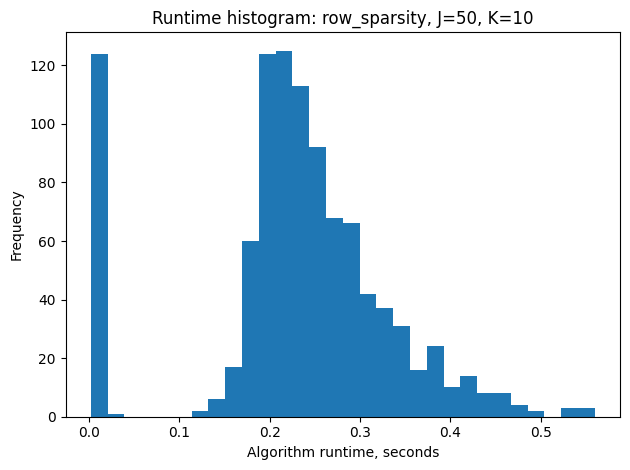

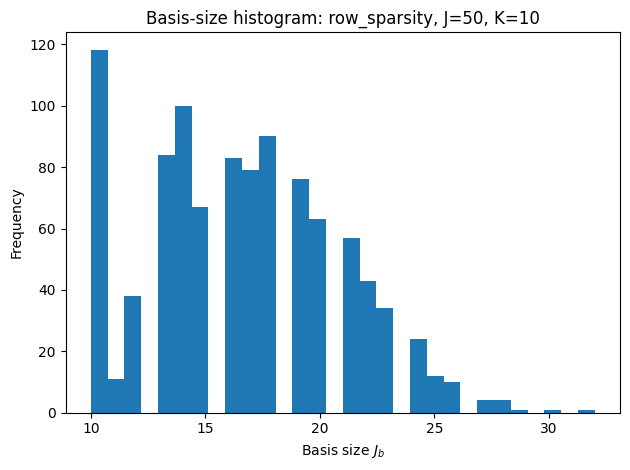

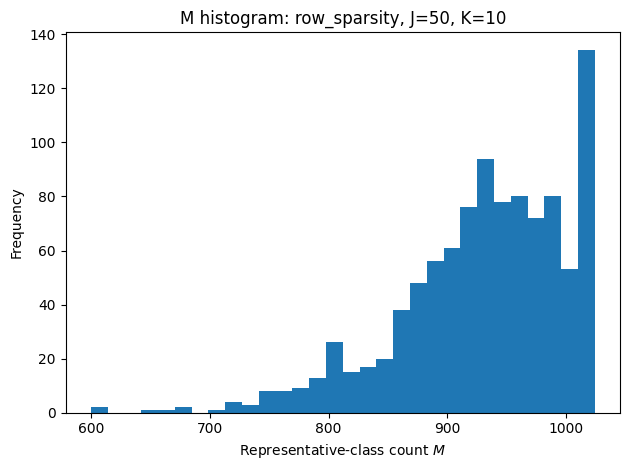

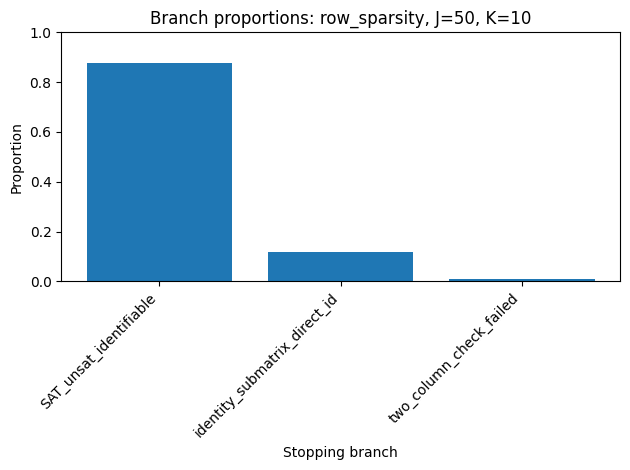

In [20]:
if len(plot_data):
    plt.figure()
    plt.hist(plot_data["algorithm_time"].dropna(), bins=30)
    plt.xlabel("Algorithm runtime, seconds")
    plt.ylabel("Frequency")
    plt.title(f"Runtime histogram: {PLOT_DESIGN}, J={PLOT_J}, K={PLOT_K}")
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"hist_runtime_{PLOT_DESIGN}_J{PLOT_J}_K{PLOT_K}.pdf")
    plt.show()

    plt.figure()
    plt.hist(plot_data["J_basis"].dropna(), bins=30)
    plt.xlabel("Basis size $J_b$")
    plt.ylabel("Frequency")
    plt.title(f"Basis-size histogram: {PLOT_DESIGN}, J={PLOT_J}, K={PLOT_K}")
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"hist_Jbasis_{PLOT_DESIGN}_J{PLOT_J}_K{PLOT_K}.pdf")
    plt.show()

    plt.figure()
    plt.hist(plot_data["M_basis"].dropna(), bins=30)
    plt.xlabel("Representative-class count $M$")
    plt.ylabel("Frequency")
    plt.title(f"M histogram: {PLOT_DESIGN}, J={PLOT_J}, K={PLOT_K}")
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"hist_Mbasis_{PLOT_DESIGN}_J{PLOT_J}_K{PLOT_K}.pdf")
    plt.show()

    branch_counts = plot_data["branch_label"].value_counts(normalize=True).sort_index()
    plt.figure()
    plt.bar(branch_counts.index.astype(str), branch_counts.values)
    plt.xlabel("Stopping branch")
    plt.ylabel("Proportion")
    plt.title(f"Branch proportions: {PLOT_DESIGN}, J={PLOT_J}, K={PLOT_K}")
    plt.xticks(rotation=45, ha="right")
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"branch_bar_{PLOT_DESIGN}_J{PLOT_J}_K{PLOT_K}.pdf")
    plt.show()
else:
    print("No rows selected. Adjust PLOT_* variables above.")

## 15. Export numeric summaries

This cell saves merged raw rows, summary CSVs, branch tables, and display tables.

In [21]:
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Merged rows.
df.to_csv(OUT_DIR / "merged_diagnostic_rows_all_designs.csv", index=False)

# Numeric summaries.
if len(bern_summary):
    bern_summary.to_csv(OUT_DIR / "bernoulli_summary_raw.csv", index=False)
    bern_branch.to_csv(OUT_DIR / "bernoulli_branch_proportions_raw.csv", index=False)
    bern_display.to_csv(OUT_DIR / "bernoulli_summary_display.csv", index=False)

if len(row_summary):
    row_summary.to_csv(OUT_DIR / "row_sparsity_summary_raw.csv", index=False)
    row_branch.to_csv(OUT_DIR / "row_sparsity_branch_proportions_raw.csv", index=False)
    row_display.to_csv(OUT_DIR / "row_sparsity_summary_display.csv", index=False)

print(f"Exported summaries to {OUT_DIR.resolve()}")
print("LaTeX tables are in:", LATEX_DIR.resolve())
print("Figures are in:", FIG_DIR.resolve())

Exported summaries to /home/lemonkey/idQ/data/processed
LaTeX tables are in: /home/lemonkey/idQ/data/processed/latex_tables
Figures are in: /home/lemonkey/idQ/data/processed/figures


## 16. Interpretation notes

- Use `identity_prop` for the classical completeness/pure-node condition on the generated \(Q\).
- Use `identity_basis_prop`, `two_col_violation_basis_prop`, and branch proportions for algorithm stopping behavior after basis reduction.
- Use `sat_called_prop` to report the fraction of simulations that actually reached SAT.
- Use `mean_sat_time_given_SAT`, not only `mean_sat_time_all`, when describing the computational cost of SAT among cases that reached it.
- For the pure-node gap, use original-\(Q\) indicators:
  - `id_and_not_complete_prop`
  - `not_complete_given_id`
  - `id_and_no_pure_prop`
  - `no_pure_given_id`
- For the applied diagnostic row-sparsity experiment, the main table should probably use rows \(m=3,4\) and columns grouped by \((J,K)\).